In [1]:
import os
import re
import glob
from pathlib import Path
from itertools import islice
from collections import Counter, defaultdict

import numpy as np
import ase.io
import matplotlib.pyplot as plt
from tqdm import tqdm

from dscribe.descriptors import SOAP
from sklearn.decomposition import IncrementalPCA, PCA
import umap

In [7]:
import os
import re
import glob

# ===== target materials =====
TARGET_MATS = ["LE_1", "HE_2", "HE_7"]

# ===== roots =====
MD_ROOT = "./xyz"
PERTURB_ROOTS = [
    "/home/jovyan/ML_HEPO/random_variation/global_npt_final/xyz",
    "/home/jovyan/ML_HEPO/random_variation/local_npt_final/xyz",
]

# ===== outputs =====
COMBINED_POOL = "compare_md_perturb_pool.extxyz"
FEATURE_NPY   = "compare_ipca50.npy"
LABELS_NPZ    = "compare_labels.npz"
OUT_DIR       = "compare_md_vs_perturb_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# parser:
# 1) LE_1__Ov00__r00__T0300K.extxyz
# 2) LE_1__Ov00__r00__T0300K__1d_compress.extxyz
# 3) LE_1__Ov00__r00__T0300K__B_disp.extxyz
pat = re.compile(
    r'(?P<mat>[^/\\]+)__Ov(?P<Ov>\d+)__r(?P<run>\d+)__T(?P<T>\d+)K(?:__(?P<perturb>.+))?\.extxyz$'
)

def parse_from_path(path):
    base = os.path.basename(path)
    m = pat.search(base)
    if not m:
        raise ValueError(f"Parse failed: {base}")
    d = m.groupdict()
    return {
        "material": d["mat"],
        "Ov": int(d["Ov"]),
        "run": int(d["run"]),
        "T": int(d["T"]),
        "perturb_tag": d["perturb"] if d["perturb"] is not None else "",
        "source_file": base
    }

# -----------------------------
# method 1: MD files
# only target materials + rep00 + NO perturb suffix
# -----------------------------
md_files = []
for mat in TARGET_MATS:
    files = sorted(glob.glob(f"{MD_ROOT}/{mat}/*.extxyz"))
    for fp in files:
        meta = parse_from_path(fp)
        if meta["run"] == 0 and meta["perturb_tag"] == "":
            md_files.append(fp)

# -----------------------------
# method 2: perturb files
# from both global_npt_final and local_npt_final
# only target materials + rep00 + MUST have perturb suffix
# -----------------------------
perturb_files = []
for root in PERTURB_ROOTS:
    for mat in TARGET_MATS:
        files = sorted(glob.glob(f"{root}/{mat}/*.extxyz"))
        for fp in files:
            meta = parse_from_path(fp)
            if meta["run"] == 0 and meta["perturb_tag"] != "":
                perturb_files.append(fp)

print("Selected MD files:", len(md_files))
for fp in md_files[:10]:
    print("  MD      ", os.path.basename(fp))

print("\nSelected perturb files:", len(perturb_files))
for fp in perturb_files[:20]:
    print("  perturb ", os.path.basename(fp))

# quick sanity check: perturb tag counts
from collections import Counter
tag_counter = Counter()
for fp in perturb_files:
    tag_counter[parse_from_path(fp)["perturb_tag"]] += 1

print("\nPerturb tag counts:")
for k, v in sorted(tag_counter.items()):
    print(f"  {k}: {v}")

Selected MD files: 75
  MD       LE_1__Ov00__r00__T0300K.extxyz
  MD       LE_1__Ov00__r00__T0500K.extxyz
  MD       LE_1__Ov00__r00__T0700K.extxyz
  MD       LE_1__Ov00__r00__T0900K.extxyz
  MD       LE_1__Ov00__r00__T1100K.extxyz
  MD       LE_1__Ov03__r00__T0300K.extxyz
  MD       LE_1__Ov03__r00__T0500K.extxyz
  MD       LE_1__Ov03__r00__T0700K.extxyz
  MD       LE_1__Ov03__r00__T0900K.extxyz
  MD       LE_1__Ov03__r00__T1100K.extxyz

Selected perturb files: 126
  perturb  LE_1__Ov00__r00__T0300K__1d_compress.extxyz
  perturb  LE_1__Ov00__r00__T0300K__1d_expand.extxyz
  perturb  LE_1__Ov00__r00__T0300K__iso_compress.extxyz
  perturb  LE_1__Ov00__r00__T0300K__iso_expand.extxyz
  perturb  LE_1__Ov00__r00__T1100K__1d_compress.extxyz
  perturb  LE_1__Ov00__r00__T1100K__1d_expand.extxyz
  perturb  LE_1__Ov00__r00__T1100K__iso_compress.extxyz
  perturb  LE_1__Ov00__r00__T1100K__iso_expand.extxyz
  perturb  LE_1__Ov06__r00__T0300K__1d_compress.extxyz
  perturb  LE_1__Ov06__r00__T0300K__1d

In [9]:
from pathlib import Path
import ase.io
from tqdm import tqdm

Path(COMBINED_POOL).unlink(missing_ok=True)

written_md = 0
written_perturb = 0

# ----- write method 1: md rep00 -----
for fp in tqdm(md_files, desc="Writing MD frames"):
    meta = parse_from_path(fp)
    for atoms in ase.io.iread(fp, index=":"):
        atoms.info["method"] = "md"
        atoms.info["material"] = meta["material"]
        atoms.info["Ov"] = meta["Ov"]
        atoms.info["T"] = meta["T"]
        atoms.info["run"] = meta["run"]
        atoms.info["perturb_tag"] = ""
        atoms.info["source_file"] = meta["source_file"]
        ase.io.write(COMBINED_POOL, atoms, append=True)
        written_md += 1

# ----- write method 2: perturb rep00 -----
for fp in tqdm(perturb_files, desc="Writing perturb frames"):
    meta = parse_from_path(fp)
    for atoms in ase.io.iread(fp, index=":"):
        atoms.info["method"] = "perturb"
        atoms.info["material"] = meta["material"]
        atoms.info["Ov"] = meta["Ov"]
        atoms.info["T"] = meta["T"]
        atoms.info["run"] = meta["run"]
        atoms.info["perturb_tag"] = meta["perturb_tag"]
        atoms.info["source_file"] = meta["source_file"]
        ase.io.write(COMBINED_POOL, atoms, append=True)
        written_perturb += 1

print("Written MD frames      :", written_md)
print("Written perturb frames :", written_perturb)
print("Combined total         :", written_md + written_perturb)
print("Saved:", COMBINED_POOL)

Writing perturb frames: 100%|██████████| 126/126 [00:33<00:00,  3.80it/s]

Written MD frames      : 15000
Written perturb frames : 1134
Combined total         : 16134
Saved: compare_md_perturb_pool.extxyz


In [10]:
method_counter = Counter()
material_counter = Counter()
cross_counter = Counter()

for atoms in tqdm(ase.io.iread(COMBINED_POOL, index=":"), desc="Sanity check combined pool"):
    method = atoms.info.get("method", "UNKNOWN")
    mat    = atoms.info.get("material", "UNKNOWN")
    method_counter[method] += 1
    material_counter[mat] += 1
    cross_counter[(method, mat)] += 1

print("\nCounts by method:")
print(dict(method_counter))

print("\nCounts by material:")
print(dict(material_counter))

print("\nCounts by (method, material):")
for k in sorted(cross_counter):
    print(k, cross_counter[k])

a0 = next(ase.io.iread(COMBINED_POOL, index="0"))
print("\nSample frame info:")
for k, v in a0.info.items():
    print(f"{k}: {v}")

Sanity check combined pool: 16134it [02:21, 114.06it/s]


Counts by method:
{'md': 15000, 'perturb': 1134}

Counts by material:
{'LE_1': 5378, 'HE_2': 5378, 'HE_7': 5378}

Counts by (method, material):
('md', 'HE_2') 5000
('md', 'HE_7') 5000
('md', 'LE_1') 5000
('perturb', 'HE_2') 378
('perturb', 'HE_7') 378
('perturb', 'LE_1') 378

Sample frame info:
total_step: 1
total_time: 1.0
step: 1
time: 1.0
method: md
material: LE_1
Ov: 0
T: 300
run: 0
perturb_tag: source_file=LE_1__Ov00__r00__T0300K.extxyz


In [11]:
# fixed species
species = sorted(["La", "Sr", "Ca", "Nd", "Y", "Gd", "Sm", "Ba", "Co", "Fe", "O"])
print("Species fixed:", species)

SOAP_R_CUT = 6.0
SOAP_NMAX = 8
SOAP_LMAX = 6
IPCA_COMPONENTS = 50

BATCH_SIZE = 500
N_JOBS = 2

def batch_iter(reader, batch_size):
    while True:
        batch = list(islice(reader, batch_size))
        if not batch:
            break
        yield batch

a0 = next(ase.io.iread(COMBINED_POOL, index="0"))
periodic_flag = bool(np.any(a0.get_pbc()))
print("periodic_flag =", periodic_flag)

soap = SOAP(
    species=species,
    periodic=periodic_flag,
    r_cut=SOAP_R_CUT,
    n_max=SOAP_NMAX,
    l_max=SOAP_LMAX,
    average="outer",
    sparse=False
)

ipca = IncrementalPCA(n_components=IPCA_COMPONENTS, batch_size=BATCH_SIZE)
print("SOAP + IPCA ready.")

Species fixed: ['Ba', 'Ca', 'Co', 'Fe', 'Gd', 'La', 'Nd', 'O', 'Sm', 'Sr', 'Y']
periodic_flag = True
SOAP + IPCA ready.


In [13]:
reader = ase.io.iread(COMBINED_POOL, index=":")
pbar = tqdm(desc="IPCA fit on combined pool", unit="frame")

for batch in batch_iter(reader, BATCH_SIZE):
    X = soap.create(batch, n_jobs=N_JOBS)
    ipca.partial_fit(X)
    pbar.update(len(batch))

pbar.close()

print("IPCA fit done.")
print("explained_var_sum =", float(ipca.explained_variance_ratio_.sum()))
print("n_components_ =", ipca.n_components_)


IPCA fit on combined pool: 1500frame [26:32,  1.06s/frame]

A fit on combined pool: 500frame [05:05,  1.63frame/s]
A fit on combined pool: 1000frame [09:52,  1.70frame/s]
A fit on combined pool: 1500frame [14:38,  1.72frame/s]
A fit on combined pool: 2000frame [19:21,  1.74frame/s]
A fit on combined pool: 2500frame [24:09,  1.74frame/s]
A fit on combined pool: 3000frame [28:57,  1.74frame/s]
A fit on combined pool: 3500frame [33:50,  1.73frame/s]
A fit on combined pool: 4000frame [38:32,  1.74frame/s]
A fit on combined pool: 4500frame [43:18,  1.74frame/s]
A fit on combined pool: 5000frame [47:59,  1.75frame/s]
A fit on combined pool: 5500frame [53:03,  1.72frame/s]
A fit on combined pool: 6000frame [57:59,  1.71frame/s]
A fit on combined pool: 6500frame [1:02:51,  1.71frame/s]
A fit on combined pool: 7000frame [1:07:46,  1.71frame/s]
A fit on combined pool: 7500frame [1:12:46,  1.69frame/s]
A fit on combined pool: 8000frame [1:17:33,  1.71frame/s]
A fit on combined pool: 8500frame [1

IPCA fit done.
explained_var_sum = 0.9999978380124789
n_components_ = 50


In [14]:
Z_chunks = []
method_chunks = []
material_chunks = []
T_chunks = []
Ov_chunks = []
run_chunks = []
perturb_tag_chunks = []

reader = ase.io.iread(COMBINED_POOL, index=":")
pbar = tqdm(desc="Transform combined pool", unit="frame")

for batch in batch_iter(reader, BATCH_SIZE):
    X = soap.create(batch, n_jobs=N_JOBS)
    Zb = ipca.transform(X).astype(np.float32)

    Z_chunks.append(Zb)
    method_chunks.append(np.array([str(a.info.get("method", "UNKNOWN")) for a in batch], dtype=object))
    material_chunks.append(np.array([str(a.info.get("material", "UNKNOWN")) for a in batch], dtype=object))
    T_chunks.append(np.array([int(a.info.get("T", -1)) for a in batch], dtype=np.int32))
    Ov_chunks.append(np.array([int(a.info.get("Ov", -1)) for a in batch], dtype=np.int32))
    run_chunks.append(np.array([int(a.info.get("run", -1)) for a in batch], dtype=np.int32))
    perturb_tag_chunks.append(np.array([str(a.info.get("perturb_tag", "")) for a in batch], dtype=object))

    pbar.update(len(batch))

pbar.close()

Z = np.vstack(Z_chunks)
method = np.concatenate(method_chunks)
material = np.concatenate(material_chunks)
T = np.concatenate(T_chunks)
Ov = np.concatenate(Ov_chunks)
run = np.concatenate(run_chunks)
perturb_tag = np.concatenate(perturb_tag_chunks)

np.save(FEATURE_NPY, Z)
np.savez(
    LABELS_NPZ,
    method=method,
    material=material,
    T=T,
    Ov=Ov,
    run=run,
    perturb_tag=perturb_tag
)

print("Saved:", FEATURE_NPY, "and", LABELS_NPZ)
print("Z shape:", Z.shape)
print("method counts:", dict(zip(*np.unique(method, return_counts=True))))
print("material counts:", dict(zip(*np.unique(material, return_counts=True))))
print("perturb tags:", dict(zip(*np.unique(perturb_tag, return_counts=True))))

Transform combined pool: 16134frame [2:33:19,  1.75frame/s]

Saved: compare_ipca50.npy and compare_labels.npz
Z shape: (16134, 50)
method counts: {'md': np.int64(15000), 'perturb': np.int64(1134)}
material counts: {'HE_2': np.int64(5378), 'HE_7': np.int64(5378), 'LE_1': np.int64(5378)}
perturb tags: {'1d_compress': np.int64(162), '1d_expand': np.int64(162), 'B_disp': np.int64(162), 'OB_disp': np.int64(162), 'O_disp': np.int64(162), 'iso_compress': np.int64(162), 'iso_expand': np.int64(162), 'source_file=HE_2__Ov00__r00__T0300K.extxyz': np.int64(200), 'source_file=HE_2__Ov00__r00__T0500K.extxyz': np.int64(200), 'source_file=HE_2__Ov00__r00__T0700K.extxyz': np.int64(200), 'source_file=HE_2__Ov00__r00__T0900K.extxyz': np.int64(200), 'source_file=HE_2__Ov00__r00__T1100K.extxyz': np.int64(200), 'source_file=HE_2__Ov03__r00__T0300K.extxyz': np.int64(200), 'source_file=HE_2__Ov03__r00__T0500K.extxyz': np.int64(200), 'source_file=HE_2__Ov03__r00__T0700K.extxyz': np.int64(200), 'source_file=HE_2__Ov03__r00__T0900K.extxyz': np.int64(200), 'source_file=HE_

In [15]:
# PCA on 50D features
pca2 = PCA(n_components=2, random_state=0)
P = pca2.fit_transform(Z)
print("PCA2 explained variance sum:", float(pca2.explained_variance_ratio_.sum()))

# UMAP on 50D features
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42
)
U = reducer.fit_transform(Z)

print("P shape:", P.shape)
print("U shape:", U.shape)

PCA2 explained variance sum: 0.946571946144104


/home/jovyan/.py313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


P shape: (16134, 2)
U shape: (16134, 2)


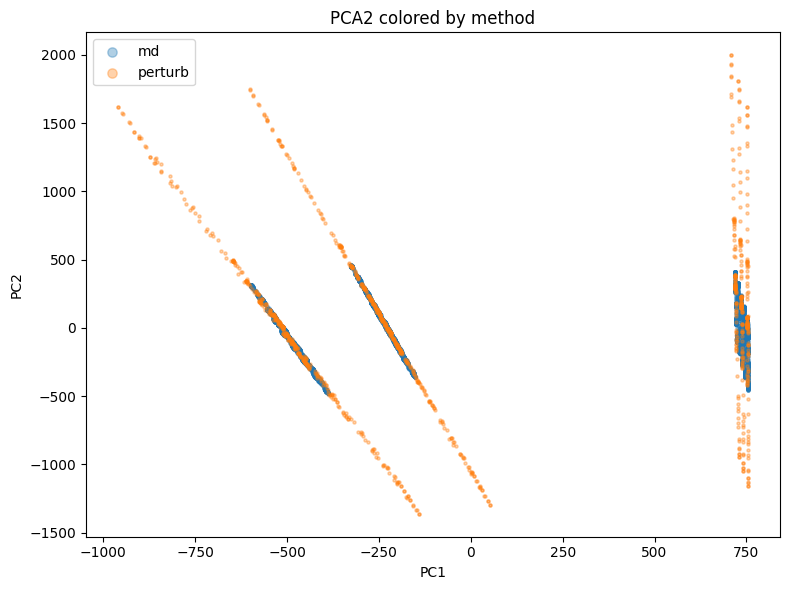

Saved: compare_md_vs_perturb_plots/pca2_by_method.png


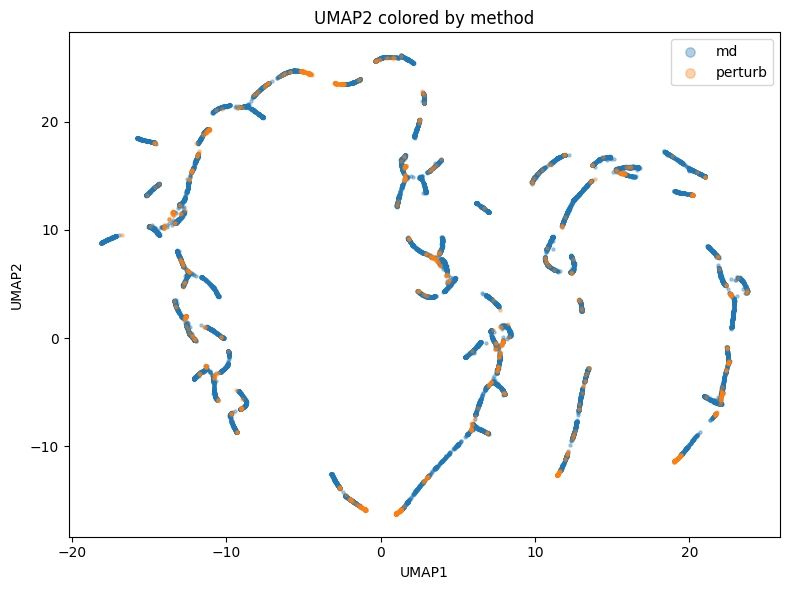

Saved: compare_md_vs_perturb_plots/umap2_by_method.png


In [16]:
def scatter_by_label(xy, labels, title, fname, alpha=0.35, s=5):
    uniq = list(np.unique(labels))
    cmap = plt.get_cmap("tab10" if len(uniq) <= 10 else "tab20")

    plt.figure(figsize=(8, 6))
    for i, lab in enumerate(uniq):
        mask = (labels == lab)
        plt.scatter(
            xy[mask, 0], xy[mask, 1],
            s=s, alpha=alpha, label=str(lab),
            color=cmap(i)
        )

    plt.xlabel(title.split()[0] if False else "")
    plt.title(title)
    plt.legend(markerscale=3, frameon=True)
    plt.tight_layout()

    out = os.path.join(OUT_DIR, fname)
    plt.savefig(out, dpi=220)
    plt.show()
    print("Saved:", out)

# PCA by method
plt.figure(figsize=(8, 6))
for i, lab in enumerate(np.unique(method)):
    mask = (method == lab)
    plt.scatter(P[mask, 0], P[mask, 1], s=5, alpha=0.35, label=lab)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA2 colored by method")
plt.legend(markerscale=3, frameon=True)
plt.tight_layout()
out = os.path.join(OUT_DIR, "pca2_by_method.png")
plt.savefig(out, dpi=220)
plt.show()
print("Saved:", out)

# UMAP by method
plt.figure(figsize=(8, 6))
for i, lab in enumerate(np.unique(method)):
    mask = (method == lab)
    plt.scatter(U[mask, 0], U[mask, 1], s=5, alpha=0.35, label=lab)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP2 colored by method")
plt.legend(markerscale=3, frameon=True)
plt.tight_layout()
out = os.path.join(OUT_DIR, "umap2_by_method.png")
plt.savefig(out, dpi=220)
plt.show()
print("Saved:", out)

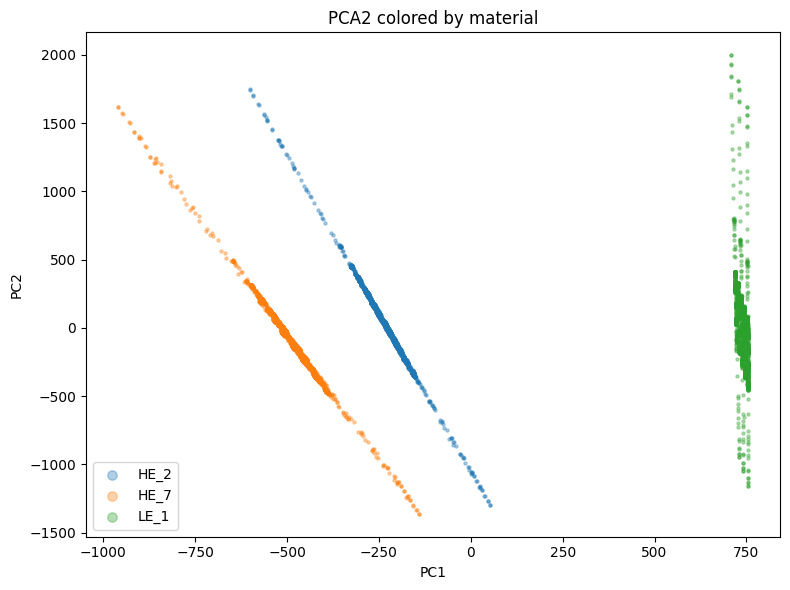

Saved: compare_md_vs_perturb_plots/pca2_by_material.png


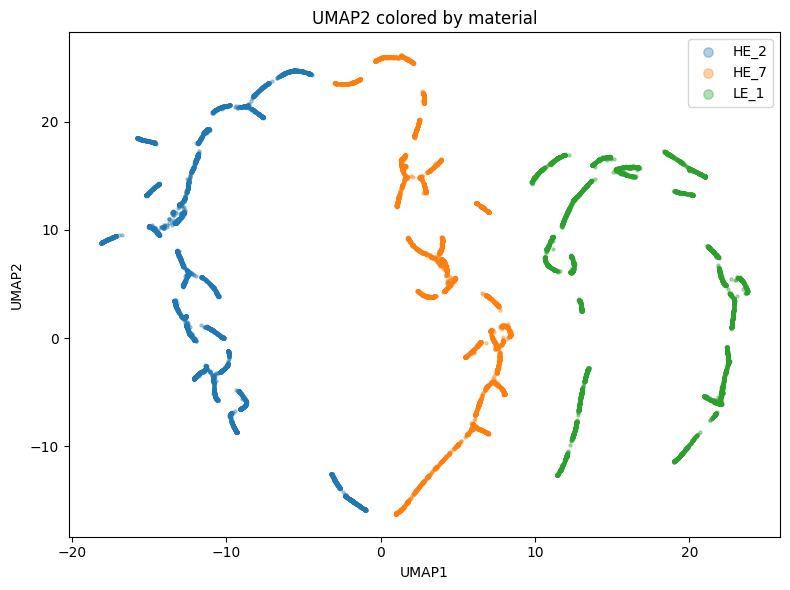

Saved: compare_md_vs_perturb_plots/umap2_by_material.png


In [17]:
# PCA by material
plt.figure(figsize=(8, 6))
for i, lab in enumerate(np.unique(material)):
    mask = (material == lab)
    plt.scatter(P[mask, 0], P[mask, 1], s=5, alpha=0.35, label=lab)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA2 colored by material")
plt.legend(markerscale=3, frameon=True)
plt.tight_layout()
out = os.path.join(OUT_DIR, "pca2_by_material.png")
plt.savefig(out, dpi=220)
plt.show()
print("Saved:", out)

# UMAP by material
plt.figure(figsize=(8, 6))
for i, lab in enumerate(np.unique(material)):
    mask = (material == lab)
    plt.scatter(U[mask, 0], U[mask, 1], s=5, alpha=0.35, label=lab)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP2 colored by material")
plt.legend(markerscale=3, frameon=True)
plt.tight_layout()
out = os.path.join(OUT_DIR, "umap2_by_material.png")
plt.savefig(out, dpi=220)
plt.show()
print("Saved:", out)

In [18]:
def dist_to_centroid(Zsub):
    c = Zsub.mean(axis=0, keepdims=True)
    d = np.linalg.norm(Zsub - c, axis=1)
    return d

print("Spread in IPCA-50D by method:")
for m in np.unique(method):
    mask = (method == m)
    d = dist_to_centroid(Z[mask])
    print(
        m,
        "n =", mask.sum(),
        "median =", float(np.median(d)),
        "p90 =", float(np.percentile(d, 90)),
        "p99 =", float(np.percentile(d, 99))
    )

Spread in IPCA-50D by method:
md n = 15000 median = 538.6427001953125 p90 = 773.9487915039062 p99 = 852.9646606445312
perturb n = 1134 median = 744.3057861328125 p90 = 1302.9771728515625 p99 = 1833.743408203125


Z shape: (16134, 50)
Methods: {'md': np.int64(15000), 'perturb': np.int64(1134)}
Materials: {'HE_2': np.int64(5378), 'HE_7': np.int64(5378), 'LE_1': np.int64(5378)}
MD points: 15000
Perturb points: 1134
MD d10 median/p10/p90: 3.833199381828308 2.47278778553009 7.493354749679567
Perturb d10 median/p10/p90: 40.17751884460449 15.208174228668215 120.40206298828126


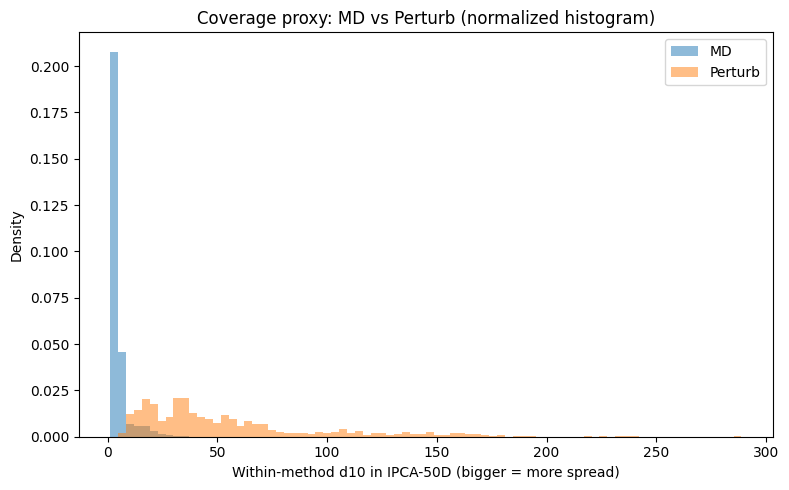

Saved: compare_md_vs_perturb_plots/md_vs_perturb_d10_hist_density.png

--- Per-material d10 comparison ---

Material: HE_2
  MD n = 5000 | Perturb n = 378
  MD      median = 3.999794125556946 p10 = 2.602785634994507 p90 = 7.049093008041383
  Perturb median = 37.13985824584961 p10 = 17.928788948059083 p90 = 115.78206481933594

Material: HE_7
  MD n = 5000 | Perturb n = 378
  MD      median = 4.046064376831055 p10 = 2.614922857284546 p90 = 6.897545433044439
  Perturb median = 39.807456970214844 p10 = 18.60850257873535 p90 = 120.46291275024414

Material: LE_1
  MD n = 5000 | Perturb n = 378
  MD      median = 3.473810911178589 p10 = 2.181123733520508 p90 = 8.580088233947755
  Perturb median = 43.261274337768555 p10 = 10.023177242279052 p90 = 124.8659408569336

Saved indices to compare_md_vs_perturb_plots


In [20]:
# Cell X — MD vs perturb: d10 histogram + per-material d10

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import os

# ---------- sanity check ----------
print("Z shape:", Z.shape)
print("Methods:", dict(zip(*np.unique(method, return_counts=True))))
print("Materials:", dict(zip(*np.unique(material, return_counts=True))))

md_idx = np.where(method == "md")[0]
pt_idx = np.where(method == "perturb")[0]

print("MD points:", len(md_idx))
print("Perturb points:", len(pt_idx))

if len(md_idx) < 11 or len(pt_idx) < 11:
    raise ValueError("Need at least 11 points in each method group to compute d10.")

# ---------- helper ----------
def dk_on_subset(Xsub, k=10):
    if len(Xsub) <= k:
        raise ValueError(f"Subset too small for k={k}: n={len(Xsub)}")
    nn = NearestNeighbors(n_neighbors=k+1).fit(Xsub)
    d, _ = nn.kneighbors(Xsub)
    return d[:, k]   # kth neighbor distance, excluding self

# ---------- compute d10 within each method ----------
d10_md = dk_on_subset(Z[md_idx], k=10)
d10_pt = dk_on_subset(Z[pt_idx], k=10)

print("MD d10 median/p10/p90:",
      float(np.median(d10_md)),
      float(np.percentile(d10_md, 10)),
      float(np.percentile(d10_md, 90)))

print("Perturb d10 median/p10/p90:",
      float(np.median(d10_pt)),
      float(np.percentile(d10_pt, 10)),
      float(np.percentile(d10_pt, 90)))

# ---------- shared bins histogram ----------
min_val = min(d10_md.min(), d10_pt.min())
max_val = max(d10_md.max(), d10_pt.max())
bins = np.linspace(min_val, max_val, 81)

plt.figure(figsize=(8,5))
plt.hist(d10_md, bins=bins, alpha=0.5, label="MD", density=True)
plt.hist(d10_pt, bins=bins, alpha=0.5, label="Perturb", density=True)
plt.xlabel("Within-method d10 in IPCA-50D (bigger = more spread)")
plt.ylabel("Density")
plt.title("Coverage proxy: MD vs Perturb (normalized histogram)")
plt.legend()
out = os.path.join(OUT_DIR, "md_vs_perturb_d10_hist_density.png")
plt.tight_layout()
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ---------- per-material comparison ----------
uniq_m = np.unique(material)

print("\n--- Per-material d10 comparison ---")
for m in uniq_m:
    md_sel = np.where((material == m) & (method == "md"))[0]
    pt_sel = np.where((material == m) & (method == "perturb"))[0]

    print(f"\nMaterial: {m}")
    print("  MD n =", len(md_sel), "| Perturb n =", len(pt_sel))

    if len(md_sel) >= 11:
        d10_m_md = dk_on_subset(Z[md_sel], k=10)
        print("  MD      median =", float(np.median(d10_m_md)),
              "p10 =", float(np.percentile(d10_m_md, 10)),
              "p90 =", float(np.percentile(d10_m_md, 90)))
    else:
        print("  MD      too few for d10")

    if len(pt_sel) >= 11:
        d10_m_pt = dk_on_subset(Z[pt_sel], k=10)
        print("  Perturb median =", float(np.median(d10_m_pt)),
              "p10 =", float(np.percentile(d10_m_pt, 10)),
              "p90 =", float(np.percentile(d10_m_pt, 90)))
    else:
        print("  Perturb too few for d10")

# ---------- save indices ----------
np.save(os.path.join(OUT_DIR, "md_idx.npy"), md_idx)
np.save(os.path.join(OUT_DIR, "perturb_idx.npy"), pt_idx)
print("\nSaved indices to", OUT_DIR)